In [7]:
# Update files
import importlib
import utils.io
import data.data_loader
import models.multi_layer_perceptron
import models.convolutional_neural_networks
import utils.metrics
import config as cfg
importlib.reload(utils.io)
importlib.reload(data.data_loader)
importlib.reload(cfg)
importlib.reload(utils.metrics)
importlib.reload(models.multi_layer_perceptron)
importlib.reload(models.convolutional_neural_networks)


# Import libraries  
import pandas as pd
import torch
import torchvision.transforms as transforms
import torch.optim as optim
import torch.utils.data as data
import torch.nn as nn
import matplotlib.pyplot as plt

# Choose device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():    
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [8]:
from data.data_loader import ButterflyDataset
from utils.io import print_images
from utils.metrics import analyze_df
from sklearn.model_selection import train_test_split

# load the data
df = pd.read_csv(cfg.TRAIN_LABELS_PATH)

df_train, df_val = train_test_split(df, test_size=cfg.TEST_SIZE, random_state=42, stratify=df['label'])

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

train_dataset = ButterflyDataset(df=df_train, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
val_dataset = ButterflyDataset(df=df_val, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)

train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
print("All images proccessed...")


All images proccessed...


#### TRAIN DATASET ####
------------------------------
Número de classes: 75
Número de inputs para o MLP: 12288
------------------------------
------------------------------
                Quantidade de Imagens  Proporção (%)
label                                               
MOURNING CLOAK                     73       2.006046
SLEEPY ORANGE                      59       1.621325
ATALA                              56       1.538884
BROWN SIPROETA                     55       1.511404
ORANGE TIP                         54       1.483924
...                               ...            ...
MALACHITE                          41       1.126683
CRIMSON PATCH                      41       1.126683
AMERICAN SNOOT                     41       1.126683
GOLD BANDED                        41       1.126683
WOOD SATYR                         40       1.099203

[75 rows x 2 columns]
------------------------------


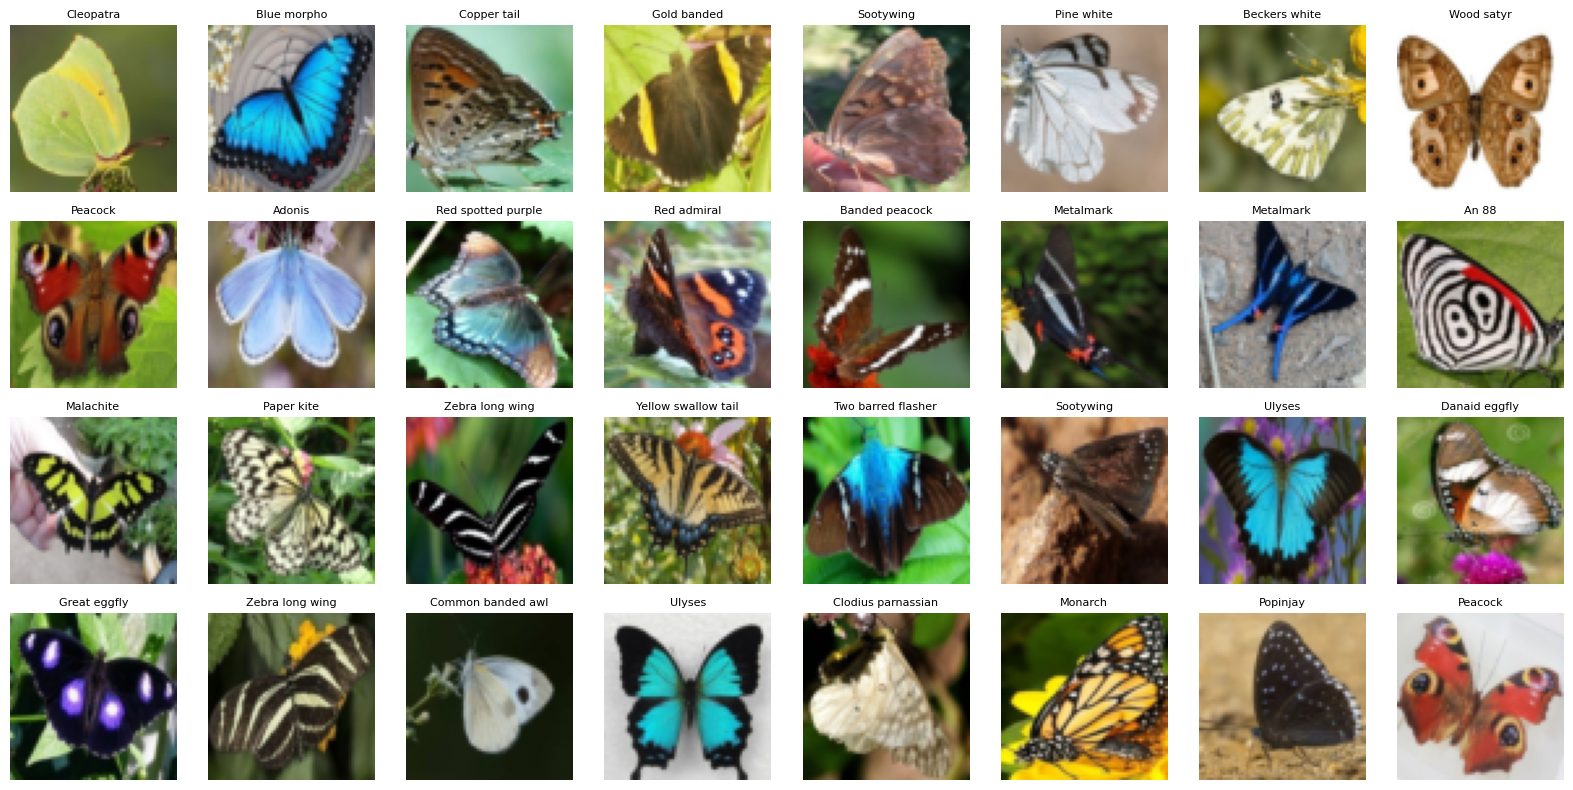

In [9]:
# Train data set analyze
print("#### TRAIN DATASET ####")
num_inputs, num_classes = analyze_df(df_train, train_dataset)
print_images(train_dataset, train_loader)

MLP

In [ ]:
import torch.nn as nn
import torch.optim as optim
from models.multi_layer_perceptron import MLP, fit

dnn = MLP(input_size=num_inputs, hidden_sizes=cfg.MLP_HIDDEN_LAYER_SIZES, num_classes=num_classes)

# Escolher Loss Function
if cfg.MLP_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.MLP_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.MLP_LABEL_SMOOTHING) 
elif cfg.MLP_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.MLP_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.MLP_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAM":
    optimizer = optim.Adam(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAMW":
    optimizer = optim.AdamW(dnn.parameters(), lr=cfg.MLP_LR, weight_decay=cfg.MLP_WEIGHT_DECAY)
elif cfg.MLP_OPTIM == "SGD":
    optimizer = optim.SGD(dnn.parameters(), lr=cfg.MLP_LR, momentum=cfg.MLP_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.MLP_OPTIM}")

# Treino
print(f"A iniciar o treino com {cfg.MLP_OPTIM} e {cfg.MLP_LOSS_FUNCTION}...")
mlp_train_acc, mlp_val_acc, dnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=dnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.MLP_EPOCHS, 
    to_device=False
)

A iniciar o treino com ADAMW e CrossEntropy...
Epoch [1/50], Train Loss: 4.2180 | Val Loss: 3.9312
Epoch [2/50], Train Loss: 3.6309 | Val Loss: 3.4859
Epoch [3/50], Train Loss: 3.3402 | Val Loss: 3.1807
Epoch [4/50], Train Loss: 3.0835 | Val Loss: 3.0823
Epoch [5/50], Train Loss: 2.8892 | Val Loss: 3.0372
Epoch [6/50], Train Loss: 2.7400 | Val Loss: 2.8621
Epoch [7/50], Train Loss: 2.5777 | Val Loss: 2.8308
Epoch [8/50], Train Loss: 2.4549 | Val Loss: 2.8184
Epoch [9/50], Train Loss: 2.3457 | Val Loss: 2.8336
Epoch [10/50], Train Loss: 2.2529 | Val Loss: 2.7069
Epoch [11/50], Train Loss: 2.1286 | Val Loss: 2.6372
Epoch [12/50], Train Loss: 2.0041 | Val Loss: 2.6210
Epoch [13/50], Train Loss: 1.9300 | Val Loss: 2.7095
Epoch [14/50], Train Loss: 1.8233 | Val Loss: 2.6899
Epoch [15/50], Train Loss: 1.7451 | Val Loss: 2.8714
Epoch [16/50], Train Loss: 1.6938 | Val Loss: 2.7902
Epoch [17/50], Train Loss: 1.5663 | Val Loss: 2.8281
Epoch [18/50], Train Loss: 1.4693 | Val Loss: 2.8661
Epoch [1

In [ ]:
from utils.metrics import evaluate_network, save_acc_graph

print('Saving graphics showing loss results...')
save_acc_graph(mlp_train_acc, mlp_val_acc, cfg.mlp_results_path, cfg.mlp_results_folder_name, "RNN")

print('Evaluating with the training data...')
evaluate_network(
    net=dnn, 
    dataloader=train_loader, 
    device="cpu",
    save_path=cfg.mlp_results_path, 
    split_name="Treino"
)

print('Evaluating with the valid data...')
evaluate_network(
    net=dnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=cfg.mlp_results_path, 
    split_name="Validacao"
)

Saving graphics showing loss results...
Gráfico guardado com sucesso...
Evaluating with the training data...
[Treino] F1 Score: 0.9682
Métricas de Treino salvas...
Evaluating with the valid data...
[Validacao] F1 Score: 0.3350
Métricas de Validacao salvas...


(0.3349853064742853,
 array([[12,  0,  0, ...,  0,  0,  0],
        [ 0,  6,  1, ...,  0,  0,  0],
        [ 0,  0,  2, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  4,  1,  0],
        [ 0,  0,  0, ...,  0,  4,  0],
        [ 0,  0,  0, ...,  0,  0,  2]]))

CNN

In [ ]:
import torch.nn as nn
import torch.optim as optim
from models.convolutional_neural_networks import CNN, fit

cnn = CNN(input_channels=3, num_classes=num_classes)

# Escolher Loss Function
if cfg.CNN_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.CNN_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.CNN_LABEL_SMOOTHING) 
elif cfg.CNN_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.CNN_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.CNN_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAM":
    optimizer = optim.Adam(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAMW":
    optimizer = optim.AdamW(cnn.parameters(), lr=cfg.CNN_LR, weight_decay=cfg.CNN_WEIGHT_DECAY)
elif cfg.CNN_OPTIM == "SGD":
    optimizer = optim.SGD(cnn.parameters(), lr=cfg.CNN_LR, momentum=cfg.CNN_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.CNN_OPTIM}")

# Treino
print(f"\nA iniciar o treino da CNN com {cfg.CNN_OPTIM} e {cfg.CNN_LOSS_FUNCTION}...")
cnn_train_acc, cnn_val_acc, cnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=cnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.CNN_EPOCHS, 
    to_device=False,
    device=device
)


A iniciar o treino da CNN com SGD e CrossEntropy...
Epoch [1/50], Train Loss: 4.3189 | Val Loss: 4.3176
Epoch [2/50], Train Loss: 4.3176 | Val Loss: 4.3163
Epoch [3/50], Train Loss: 4.3159 | Val Loss: 4.3150
Epoch [4/50], Train Loss: 4.3145 | Val Loss: 4.3134
Epoch [5/50], Train Loss: 4.3130 | Val Loss: 4.3115
Epoch [6/50], Train Loss: 4.3107 | Val Loss: 4.3088
Epoch [7/50], Train Loss: 4.3075 | Val Loss: 4.3051
Epoch [8/50], Train Loss: 4.3044 | Val Loss: 4.2998
Epoch [9/50], Train Loss: 4.2962 | Val Loss: 4.2904
Epoch [10/50], Train Loss: 4.2908 | Val Loss: 4.2771
Epoch [11/50], Train Loss: 4.2713 | Val Loss: 4.2489
Epoch [12/50], Train Loss: 4.2280 | Val Loss: 4.1829
Epoch [13/50], Train Loss: 4.1676 | Val Loss: 4.0891
Epoch [14/50], Train Loss: 4.0763 | Val Loss: 3.9891
Epoch [15/50], Train Loss: 3.9821 | Val Loss: 3.8699
Epoch [16/50], Train Loss: 3.8721 | Val Loss: 3.7684
Epoch [17/50], Train Loss: 3.7749 | Val Loss: 3.6386
Epoch [18/50], Train Loss: 3.6692 | Val Loss: 3.5336
Ep

In [ ]:
from utils.metrics import evaluate_network, save_loss_graph

print('Saving graphics showing loss results...')
save_acc_graph(cnn_train_acc, cnn_val_acc, cfg.cnn_results_path, cfg.cnn_results_folder_name, "CNN")

print('Evaluating with the training data...')
evaluate_network(
    net=cnn, 
    dataloader=train_loader, 
    device="cpu",
    save_path=cfg.cnn_results_path, 
    split_name="Treino",
    is_cnn = "True"
)

print('Evaluating with the valid data...')
evaluate_network(
    net=cnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=cfg.cnn_results_path, 
    split_name="Validacao",
    is_cnn = "True"
)

Saving graphics showing loss results...
Gráfico guardado com sucesso...
Evaluating with the training data...
[Treino] F1 Score: 0.7852
Métricas de Treino salvas...
Evaluating with the valid data...
[Validacao] F1 Score: 0.4261
Métricas de Validacao salvas...


(0.42614907838810767,
 array([[16,  0,  0, ...,  1,  0,  0],
        [ 0, 12,  0, ...,  0,  0,  0],
        [ 0,  0,  2, ...,  0,  1,  0],
        ...,
        [ 0,  0,  0, ...,  8,  0,  0],
        [ 0,  0,  0, ...,  0,  7,  0],
        [ 0,  0,  0, ...,  0,  0,  9]], shape=(75, 75)))